# Refine template from an HDF5 match template result

This notebook converts an MRC match template result into a single HDF5 file, builds an HDF5 particle stack from it, and runs the refine template program on that stack.
Data used in this notebook are hosted on [Zenodo](https://zenodo.org/records/15426374).
A CUDA GPU is required for the refinement step.

In [1]:
"""MRC match template result -> HDF5 particle stack -> refine template."""

import subprocess
from pathlib import Path

import matplotlib.pyplot as plt

from leopard_em.pydantic_models.data_structures import (
    ParticleStackHDF5,
    export_particle_stack,
)
from leopard_em.pydantic_models.managers import (
    MatchTemplateManager,
    RefineTemplateManager,
)
from leopard_em.pydantic_models.results import MatchTemplateResultHDF5

MATCH_TEMPLATE_CONFIG_PATH = "xenon_216_000_0.0_DWS_config.yaml"
MATCH_TEMPLATE_HDF5_PATH = "xenon_216_000_0_match_template.h5"
PARTICLE_STACK_PATH = "xenon_216_000_0_particle_stack.h5"
REFINE_CONFIG_PATH = "refine_template_config.yaml"
REFINED_STACK_PATH = "xenon_216_000_0_refined.h5"

## 1. Download example data

Downloads the match template config, its eight MRC result maps, the micrograph, and the template (~1 GB) into the current directory.

In [2]:
download_files = [
    "xenon_216_000_0.0_DWS_config.yaml",
    "xenon_216_000_0.0_DWS.mrc",
    "60S_map_px0.936_bscale0.5.mrc",
    "xenon_216_000_0_output_mip.mrc",
    "xenon_216_000_0_output_scaled_mip.mrc",
    "xenon_216_000_0_output_orientation_phi.mrc",
    "xenon_216_000_0_output_orientation_theta.mrc",
    "xenon_216_000_0_output_orientation_psi.mrc",
    "xenon_216_000_0_output_relative_defocus.mrc",
    "xenon_216_000_0_output_correlation_average.mrc",
    "xenon_216_000_0_output_correlation_variance.mrc",
]
missing_files = [f for f in download_files if not Path(f).exists()]
missing_files

[]

In [3]:
# Only execute if missing files are found
if missing_files:
    zenodo_get_command = ["zenodo_get", "https://doi.org/10.5281/zenodo.15426374"]
    for f in missing_files:
        zenodo_get_command += ["--glob", f]

    subprocess.run(zenodo_get_command)
else:
    print("All files already exist, skipping download.")

All files already exist, skipping download.


## 2. Convert the MRC result to HDF5

The downloaded config points `match_template_result` at one MRC file per result map.
`MatchTemplateResultHDF5` stores all eight maps, plus the size of the search space, in one file.

In [4]:
mt_manager = MatchTemplateManager.from_yaml(MATCH_TEMPLATE_CONFIG_PATH)
mrc_result = mt_manager.match_template_result
mrc_result.load_tensors_from_paths()

In [5]:
# MRC files do not record the search space size, so recompute it from the config
num_orientations = mt_manager.orientation_search_config.euler_angles.shape[0]
num_defocus = mt_manager.defocus_search_config.defocus_values.numel()

result_maps = (
    "mip",
    "scaled_mip",
    "correlation_average",
    "correlation_variance",
    "orientation_psi",
    "orientation_theta",
    "orientation_phi",
    "relative_defocus",
)

hdf5_result = MatchTemplateResultHDF5(
    hdf5_path=MATCH_TEMPLATE_HDF5_PATH,
    allow_file_overwrite=True,
    total_orientations=num_orientations,
    total_defocus=num_defocus,
    total_projections=num_orientations * num_defocus,
    **{name: getattr(mrc_result, name) for name in result_maps},
)
hdf5_result.to_hdf5()

In [6]:
mt_manager.match_template_result = MatchTemplateResultHDF5.from_hdf5(
    MATCH_TEMPLATE_HDF5_PATH
)
print(mt_manager.match_template_result.total_projections, "total correlations")

20598240 total correlations


## 3. Build an HDF5 particle stack

`results_to_dataframe` picks particles from the z-score map.
Every `*_path` column of the resulting table points at the HDF5 result file.

In [7]:
df = mt_manager.results_to_dataframe()
df[["pos_x", "pos_y", "scaled_mip", "mip_path", "correlation_variance_path"]].head()

,pos_x,pos_y,scaled_mip,mip_path,correlation_variance_path
0,3470,3336,12.104484,xenon_216_000_0_match_template.h5,xenon_216_000_0_match_template.h5
1,3322,1945,11.758850,xenon_216_000_0_match_template.h5,xenon_216_000_0_match_template.h5
2,1842,3353,11.681293,xenon_216_000_0_match_template.h5,xenon_216_000_0_match_template.h5
3,133,3452,11.189375,xenon_216_000_0_match_template.h5,xenon_216_000_0_match_template.h5
4,1811,3249,11.041210,xenon_216_000_0_match_template.h5,xenon_216_000_0_match_template.h5


### (optional) Export particle stack with images and statistics maps embedded

This saves the image data alongside the per-particle parameters and statistics maps from the match template program in a single HDF5 file. _Note that global whitening and normalization are not possible when images are embedded in the particle stack file._

In [8]:
# particle_stack = ParticleStackHDF5(
#     hdf5_path=PARTICLE_STACK_PATH,
#     extracted_box_size=(528, 528),
#     original_template_size=(512, 512),
#     skip_df_load=True,  # don't read hdf5_path
# )
# particle_stack._set_dataframe(df)

# # Pre-extract images and statistics maps
# images, indices = particle_stack.load_images_grouped_by_column("micrograph_path")
# particle_stack.construct_image_stack(
#     images, indices, particle_stack.extracted_box_size, padding_mode="reflect"
# )
# particle_stack.local_stats.update(particle_stack.get_local_stat_maps())

# # Save particle stack to file with pre-extracted images and local statistics maps
# particle_stack.to_hdf5(include_image_stack=True, include_local_stats=True)

### Export only per-particle data (no images) in a single HDF5 file

In [9]:
particle_stack = export_particle_stack(
    df,
    PARTICLE_STACK_PATH,
    extracted_box_size=(528, 528),
    original_template_size=(512, 512),
)
print(f"{particle_stack.num_particles} particles written to {PARTICLE_STACK_PATH}")

198 particles written to xenon_216_000_0_particle_stack.h5


## 4. Run refine template

The particle stack only needs `hdf5_path`; box sizes are read from the file.

In [10]:
%%writefile refine_template_config.yaml
template_volume_path: 60S_map_px0.936_bscale0.5.mrc
particle_stack:
  hdf5_path: xenon_216_000_0_particle_stack.h5
defocus_refinement_config:
  enabled: true
  defocus_min: -100.0
  defocus_max: 100.0
  defocus_step: 20.0
orientation_refinement_config:
  enabled: true
  psi_step_coarse: 1.5
  psi_step_fine: 0.15
  theta_step_coarse: 2.5
  theta_step_fine: 0.25
pixel_size_refinement_config:
  enabled: false
preprocessing_filters:
  whitening_filter:
    enabled: true
    max_freq: 0.5
computational_config:
  gpu_ids: [0]
  num_cpus: 1
movie_config:
  enabled: false

Overwriting refine_template_config.yaml


In [11]:
rt_manager = RefineTemplateManager.from_yaml(REFINE_CONFIG_PATH)
rt_manager.run_refine_template(REFINED_STACK_PATH)

/home/mgiammar/git_repositories/Leopard-EM/src/leopard_em/pydantic_models/managers/refine_template_manager.py:139: UserWarning: Refined angles not found in DataFrame, using original angles...
  euler_angles = self.particle_stack.get_euler_angles(prefer_refined_angles)
/home/mgiammar/git_repositories/Leopard-EM/src/leopard_em/pydantic_models/data_structures/particle_stack.py:766: UserWarning: Refined defocus values not found in DataFrame, using original defocus values...
  particle_defocus = self.get_relative_defocus(prefer_refined_defocus)
Refining particles on device 0...: 100%|█| 198/198 [00:51<00:00,  3.84particle/
/home/mgiammar/git_repositories/Leopard-EM/src/leopard_em/pydantic_models/managers/refine_template_manager.py:492: UserWarning: Refined defocus values not found in DataFrame, using original defocus values...
  + self.particle_stack.get_relative_defocus().cpu().numpy()


## 5. Inspect the refined particles

The output is itself an HDF5 particle stack, so it can be passed to further programs the same way.

In [12]:
refined_df = ParticleStackHDF5(hdf5_path=REFINED_STACK_PATH).get_dataframe_copy()
refined_df[
    [
        "particle_id",
        "scaled_mip",
        "refined_scaled_mip",
        "refined_relative_defocus",
        "refined_phi",
        "refined_theta",
        "refined_psi",
    ]
].head()

,particle_id,scaled_mip,refined_scaled_mip,refined_relative_defocus,refined_phi,refined_theta,refined_psi
0,xenon_216_000_0.0_DWS_00000,12.104484,11.832799,260.0,302.199738,90.138710,301.291992
1,xenon_216_000_0.0_DWS_00001,11.758850,11.380017,680.0,11.194089,137.743927,118.581306
2,xenon_216_000_0.0_DWS_00002,11.681293,11.540279,740.0,111.272743,22.500002,19.500000
3,xenon_216_000_0.0_DWS_00003,11.189375,11.060553,20.0,296.690887,64.881706,166.743134
4,xenon_216_000_0.0_DWS_00004,11.041210,11.049655,360.0,51.877953,129.702911,242.476135


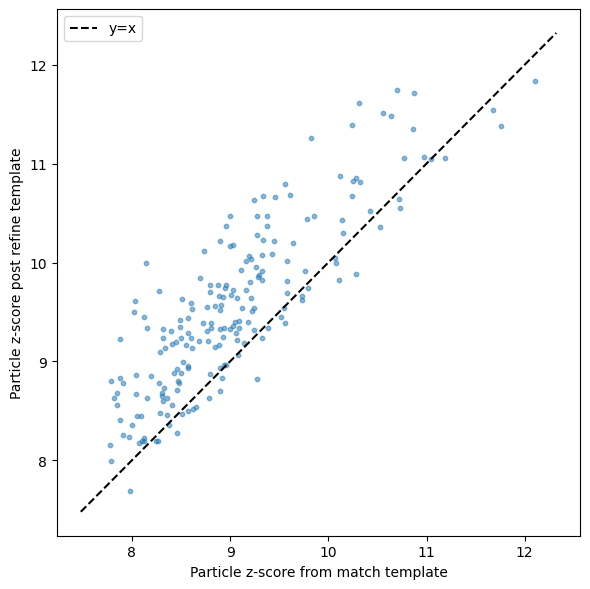

In [13]:
refined_df.plot.scatter(
    x="scaled_mip", y="refined_scaled_mip", alpha=0.5, s=10, figsize=(6, 6)
)
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
min_val = min(xmin, ymin)
max_val = max(xmax, ymax)
plt.plot(
    [min_val, max_val], [min_val, max_val], color="black", linestyle="--", label="y=x"
)
plt.xlabel("Particle z-score from match template")
plt.ylabel("Particle z-score post refine template")
plt.legend()
plt.tight_layout()
plt.show()